In [1]:
!pip install fcsparser

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 92.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 

In [1]:
import pandas as pd

from matplotlib import pyplot as plt
from matplotlib import cm

In [2]:
import subprocess
import os
import shutil

def unzip_with_password(zip_file_path, extract_path, password):
    if os.path.exists(extract_path):
        print(f"The directory '{extract_path}' already exists. Please choose a different directory.")
        return
    try:
        # Construct the 7z command
        command = [
            "7z",
            "x",
            zip_file_path,
            "-o" + extract_path,
            "-p" + password,
            "-aos"  # Overwrite all existing files without prompting
        ]

        # Execute the command
        process = subprocess.run(command, capture_output=True, text=True, check=True)

        print("Unzip successful!")
        print(process.stdout)

    except subprocess.CalledProcessError as e:
        print(f"Error during unzip: {e}")
        print(f"Standard error: {e.stderr}")
    except FileNotFoundError:
        print("7z not found. Please make sure it's installed and in your PATH.")

def delete_folder(folder_to_delete):
  try:
      if os.path.exists(folder_to_delete):
          shutil.rmtree(folder_to_delete)
          print(f"Folder '{folder_to_delete}' and its contents have been deleted successfully.")
      else:
          print(f"Folder '{folder_to_delete}' does not exist.")
  except OSError as e:
      print(f"Error deleting folder: {e}")

In [5]:
import numpy as np
from scipy.stats import linregress, gaussian_kde
def get_idr(day, cell_count, sw = 3):

  day_round = np.round(day,1)
  cell_count = np.round(cell_count,0)

  new_day = []
  new_cell_count = []

  for d in np.unique(day_round):
    new_day.append(d)
    new_cell_count.append(np.mean(cell_count[day_round==d]))

  time = np.array(new_day)
  log2cd = np.log2(new_cell_count)

  idr_list = []
  time_list = []

  for i in range(sw, len(log2cd)+1):
    time_array = time[i-sw:i]
    #print(time_array)
    if np.max(time_array)>np.min(time_array):
      #print(time_array, log2cd[i-sw:i])
      LR = linregress(time_array,log2cd[i-sw:i])
      #print(LR)
      for idr in [LR.slope, LR.slope+LR.stderr, LR.slope-LR.stderr]:
        idr_list.append([idr, idr, idr, idr])
        time_list.append([np.max(time_array), np.median(time_array), np.mean(time_array), np.min(time_array)])

  time_list = np.array(time_list).flatten()
  idr_list = np.array(idr_list).flatten()

  sel_bool = (time_list>=0)

  #interpolation fit
  unique_time = np.unique(np.round(time_list,0))
  idr_median = []
  for ut in unique_time:
    idr_group = idr_list[abs(time_list-ut)<=0.5]
    median_idr = np.median(idr_group)
    idr_median.append(median_idr)

  t_fit = np.arange(np.min(time_list[sel_bool]), np.max(time_list[sel_bool]), 0.1)
  y_interp = np.interp(t_fit, unique_time, idr_median)

  idr_ = np.array([np.mean(y_interp[abs(t_fit-y_base)<1]) for y_base in day])

  return idr_

In [4]:
import gdown

cell_count_file_url = "https://drive.google.com/uc?id=1DQ9IonY4P2J3rz02a1CmjkkSr2qR7dLC"
output_path = "/content/CC_2025_03_12_LSUCC0530_NH4_Temperature.xlsx"
gdown.download(cell_count_file_url, output_path, quiet=False)

flow_cytometry_files_zip_url = "https://drive.google.com/uc?id=1R3TlcsrvXXfi2UNtGha79QGGnL0bkcYN"
output_path = "/content/Cheng_project1_Marine_taxa_cell_cycle.zip"
gdown.download(flow_cytometry_files_zip_url, output_path, quiet=False)

target_file = "/content/Cheng_project1_Marine_taxa_cell_cycle.zip"
target_folder = "/content/Flow_cytometry_files/"
unzip_with_password(target_file, target_folder, password='')

Downloading...
From: https://drive.google.com/uc?id=1DQ9IonY4P2J3rz02a1CmjkkSr2qR7dLC
To: /content/CC_2025_03_12_LSUCC0530_NH4_Temperature.xlsx
100%|██████████| 38.6k/38.6k [00:00<00:00, 20.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1R3TlcsrvXXfi2UNtGha79QGGnL0bkcYN
From (redirected): https://drive.google.com/uc?id=1R3TlcsrvXXfi2UNtGha79QGGnL0bkcYN&confirm=t&uuid=a81dbe2c-5747-45b5-b518-04e9411e5d6c
To: /content/Cheng_project1_Marine_taxa_cell_cycle.zip
100%|██████████| 1.08G/1.08G [00:10<00:00, 99.5MB/s]


Unzip successful!

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
1 file, 1080525473 bytes (1031 MiB)

Extracting archive: /content/Cheng_project1_Marine_taxa_cell_cycle.zip
--
Path = /content/Cheng_project1_Marine_taxa_cell_cycle.zip
Type = zip
Physical Size = 1080525473

Everything is Ok

Folders: 8
Files: 135
Size:       1089137163
Compressed: 1080525473



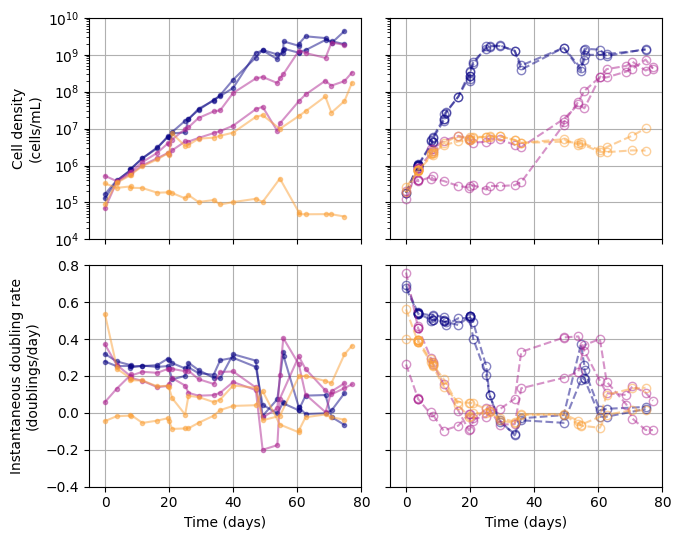

In [6]:
file_path = '/content/CC_2025_03_12_LSUCC0530_NH4_Temperature.xlsx'
df = pd.read_excel(file_path)
df['Time'] = pd.to_datetime(df['Time'])
df['Days'] = (df['Time'] - df['Time'].min()).dt.total_seconds()/3600/24

fig, axs = plt.subplots(2, 2, figsize=(7, 5.5))

color_i = 60
cmap = cm.plasma

ax = axs[0][0]
ax1 = axs[1][0]
for sample in [1,2]:
  pp = df.loc[df['Flask'] == sample, ['Days', 'Cell density (cells/mL)']].dropna().T.values
  time = pp[0]
  cell_density=pp[1]

  ax.plot(time, cell_density,'.-', color=cmap(0), alpha=0.5)

  idr = get_idr(time, cell_density)
  ax1.plot(time, idr,'.-', color=cmap(0), alpha=0.5)

for sample in [3,4]:
  pp = df.loc[df['Flask'] == sample, ['Days', 'Cell density (cells/mL)']].dropna().T.values
  time = pp[0]
  cell_density=pp[1]

  ax.plot(time, cell_density,'.-', color=cmap(100), alpha=0.5)

  idr = get_idr(time, cell_density)
  ax1.plot(time, idr,'.-', color=cmap(100), alpha=0.5)

for sample in [5,6]:
  pp = df.loc[df['Flask'] == sample, ['Days', 'Cell density (cells/mL)']].dropna().T.values
  time = pp[0]
  cell_density=pp[1]

  ax.plot(time, cell_density,'.-', color=cmap(200), alpha=0.5)

  idr = get_idr(time, cell_density)
  ax1.plot(time, idr,'.-', color=cmap(200), alpha=0.5)

ax = axs[0][1]
ax1 = axs[1][1]
for sample in [7,8]:
  pp = df.loc[df['Flask'] == sample, ['Days', 'Cell density (cells/mL)']].dropna().T.values
  time = pp[0]
  cell_density=pp[1]

  ax.plot(time, cell_density,'o--', color=cmap(0), alpha=0.5, mfc='none')

  idr = get_idr(time, cell_density)
  ax1.plot(time, idr,'o--', color=cmap(0), alpha=0.5, mfc='none')

for sample in [9,10]:
  pp = df.loc[df['Flask'] == sample, ['Days', 'Cell density (cells/mL)']].dropna().T.values
  time = pp[0]
  cell_density=pp[1]

  ax.plot(time, cell_density,'o--', color=cmap(100), alpha=0.5, mfc='none')

  idr = get_idr(time, cell_density)
  ax1.plot(time, idr,'o--', color=cmap(100), alpha=0.5, mfc='none')

for sample in [11,12]:
  pp = df.loc[df['Flask'] == sample, ['Days', 'Cell density (cells/mL)']].dropna().T.values
  time = pp[0]
  cell_density=pp[1]

  ax.plot(time, cell_density,'o--', color=cmap(200), alpha=0.5, mfc='none')

  idr = get_idr(time, cell_density)
  ax1.plot(time, idr,'o--', color=cmap(200), alpha=0.5, mfc='none')

for ax in axs.flatten():
  ax.set_xlim(-5, 80)
  ax.grid('on')

for ax in axs[0]:
  ax.set_xticklabels([])
  ax.set_yscale('log', base=10)
  ax.set_ylim(1e4, 1e10)

for ax in axs[1]:
  ax.set_xlabel('Time (days)')
  ax.set_ylim(-0.4,0.8)

axs[0][0].set_ylabel('Cell density\n(cells/mL)')
axs[0][1].set_yticklabels([])

axs[1][0].set_ylabel('Instantaneous doubling rate\n(doublings/day)')
axs[1][1].set_yticklabels([])

fig.tight_layout()
plt.show()

In [8]:
import fcsparser
import json

extracting_accuri_files = df['Accuri file'].unique()

password = "BD*ddzuvkyop"

for i in range(len(extracting_accuri_files)):
  target_file = '/content/Flow_cytometry_files'+extracting_accuri_files[i].replace('\\', '/')
  if '.ciplus' in target_file:
    target_folder = target_file.replace('.ciplus', '/')
    unzip_with_password(target_file, target_folder, password)

for i in df.index:
  if '.ciplus' in df.loc[i, 'Accuri file']:
    fcs_file_path = '/content/Flow_cytometry_files'+df.loc[i, 'Accuri file'].replace('\\', '/').replace('.ciplus', '/')+'Sample '+df.loc[i,'Well']+'.fcs'
    if os.path.exists(fcs_file_path):
      df.loc[i, 'FCS file'] = fcs_file_path
  else:
    ploidy_file_path = '/content/Flow_cytometry_files'+df.loc[i, 'Accuri file'].replace('\\', '/').replace('.fcs', '/')+df.loc[i,'Well']+'_ploidy.json'
    if os.path.exists(ploidy_file_path):
      df.loc[i, 'Ploidy file'] = ploidy_file_path

Unzip successful!

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
1 file, 31024154 bytes (30 MiB)

Extracting archive: /content/Flow_cytometry_files/Cheng_project1_Marine_taxa_cell_cycle/Data/Culture_record_Accuri_data/2025_02_25_Glc_Gly_2_5_1_Gradient_0108_transfer/accuri_20250312-2.ciplus
--
Path = /content/Flow_cytometry_files/Cheng_project1_Marine_taxa_cell_cycle/Data/Culture_record_Accuri_data/2025_02_25_Glc_Gly_2_5_1_Gradient_0108_transfer/accuri_20250312-2.ciplus
Type = zip
Physical Size = 31024154

Everything is Ok

Files: 117
Size:       31001386
Compressed: 31024154

Unzip successful!

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the driv

In [9]:
manual_fl_cutoff = 6000
histogram_bin_coeff = 500
HA_ratio_cutoff = 0.05
gaussian_bw = 0.1

for i in df.index:
  if pd.isna(df.loc[i, 'FCS file']):
    continue
  else:
    cell_count = df.loc[i, 'Count']
    fcs_file = df.loc[i,'FCS file']
    print('Processing Flask '+str(df.loc[i, 'Flask'])+'||Time '+ str(df.loc[i, 'Time'])+'||FCS file'+fcs_file)

    meta, data = fcsparser.parse(fcs_file,
                                 meta_data_only=False,
                                reformat_meta=False)

    fit_data=data[['FITC-H','FITC-A', 'PE-H']]

    non_cell_data_0 = fit_data[(fit_data['FITC-H']<=manual_fl_cutoff) | (fit_data['FITC-H']>=manual_fl_cutoff*10)]
    fit_data=fit_data[(fit_data['FITC-H']>manual_fl_cutoff) & (fit_data['FITC-H']<manual_fl_cutoff*100)]

    if len(data)>cell_count:
      YG_ratio = fit_data['PE-H']/fit_data['FITC-H']
      YG_ratio_l, YG_ratio_u = np.percentile(YG_ratio, [0.1, 99.9])

      if YG_ratio_u >= 0.35:
        YG_ratio_u = 0.35

      #YG_ratio_u = 0.25
      #YG_ratio_l = 0.15

      HA_ratio = fit_data['FITC-H']/fit_data['FITC-A']
      HA_ratio_l, HA_ratio_u = np.percentile(HA_ratio, [0.1, 99.9])

      non_cell_data_1 = fit_data[(YG_ratio<=YG_ratio_l) | (YG_ratio>=YG_ratio_u) | (HA_ratio<=HA_ratio_l) | (HA_ratio>=HA_ratio_u)]

      if abs(np.log2(len(fit_data)/cell_count))<1:
        fit_data = fit_data[(YG_ratio>YG_ratio_l) & (YG_ratio<YG_ratio_u) & (HA_ratio>HA_ratio_l) & (HA_ratio<HA_ratio_u)]

        YG_ratio = fit_data['PE-H']/fit_data['FITC-H']
        YG_median = np.median(YG_ratio)
        YG_std = np.std(YG_ratio)

        HA_ratio = fit_data['FITC-H']/fit_data['FITC-A']
        HA_median = np.median(HA_ratio)
        HA_std = np.std(HA_ratio)

        if abs(np.log2(len(fit_data)/cell_count))<1:
          cell_data = fit_data[(abs(YG_ratio-YG_median)<2*YG_std) & (abs(HA_ratio-HA_median)<2*HA_std)]
          non_cell_data = fit_data[(abs(YG_ratio-YG_median)>=2*YG_std) & (abs(HA_ratio-HA_median)>=2*HA_std)]
          all_non_cell_data = pd.concat([non_cell_data_0, non_cell_data_1])

          #(day, cell_density_auto, cell_density_manual) = (df.loc[i,'Days'],
          #                                                (len(cell_data)/float(meta['$VOL'])*1e6*
          #                                                df.loc[i, 'Total well volume (µL)']
          #                                                /df.loc[i, 'Sample volume (µL)']),
          #                                                df.loc[i, 'Cell density (cells/mL)'])

          round_ratio = np.round(HA_ratio, 1)
          round_ratio_unique = np.unique(round_ratio)

          data_sel = np.array([])

          for rru in round_ratio_unique:
            temp_cell_data = cell_data['FITC-A'][abs(HA_ratio-rru)<=HA_ratio_cutoff]

            if len(temp_cell_data)>=5:
              while (temp_cell_data.max()-temp_cell_data.min())<histogram_bin_coeff:
                histogram_bin_coeff = histogram_bin_coeff/2
              bin_num = int((temp_cell_data.max()-temp_cell_data.min())/histogram_bin_coeff)
              (count, channel) = np.histogram(temp_cell_data, bins=bin_num)

              base_count=0
              count_bool = (count>base_count)

              output_data_0 = [channel[0:-1][count_bool], count[count_bool]]

              G1_location = output_data_0[0][np.argmax(output_data_0[1])]
              while G1_location > 20000:
                G1_location = G1_location/2

              data_sel = np.r_[data_sel, temp_cell_data/G1_location]

          G1_correction = 1.0
          if len(data_sel)>50:
            gk_function=gaussian_kde(data_sel/G1_correction,
                                    bw_method=gaussian_bw/data_sel.max()
                                    )
            X_range=np.arange(0,
                              np.round(data_sel.max()/G1_correction,0)+1,
                              0.01)
            gd=gk_function(X_range)
            gd=gd/gd.max()

            # Create the dictionary
            output_dict = dict(zip(X_range, gd))

            # Specify the file path for the JSON file
            json_file_path = fcs_file.replace('Sample ', '').replace('.fcs', '_ploidy.json')

            # Save the dictionary to a JSON file
            with open(json_file_path, 'w') as json_file:
                json.dump(output_dict, json_file)

            df.loc[i, 'Ploidy file'] = json_file_path
            print('Ploidy file saved:'+json_file_path)

Processing Flask 1||Time 2025-03-13 06:35:00||FCS file/content/Flow_cytometry_files/Cheng_project1_Marine_taxa_cell_cycle/Data/Culture_record_Accuri_data/2025_02_25_Glc_Gly_2_5_1_Gradient_0108_transfer/accuri_20250312-2/Sample D01.fcs
Ploidy file saved:/content/Flow_cytometry_files/Cheng_project1_Marine_taxa_cell_cycle/Data/Culture_record_Accuri_data/2025_02_25_Glc_Gly_2_5_1_Gradient_0108_transfer/accuri_20250312-2/D01_ploidy.json
Processing Flask 2||Time 2025-03-13 06:35:00||FCS file/content/Flow_cytometry_files/Cheng_project1_Marine_taxa_cell_cycle/Data/Culture_record_Accuri_data/2025_02_25_Glc_Gly_2_5_1_Gradient_0108_transfer/accuri_20250312-2/Sample D02.fcs
Ploidy file saved:/content/Flow_cytometry_files/Cheng_project1_Marine_taxa_cell_cycle/Data/Culture_record_Accuri_data/2025_02_25_Glc_Gly_2_5_1_Gradient_0108_transfer/accuri_20250312-2/D02_ploidy.json
Processing Flask 3||Time 2025-03-13 06:35:00||FCS file/content/Flow_cytometry_files/Cheng_project1_Marine_taxa_cell_cycle/Data/Cul

In [10]:
#Cooper-Helmstetter Index
def interpolate_x_y(x,y):
  x = np.array(x)
  y = np.array(y)

  sort_bool = np.argsort(x)
  x = x[sort_bool]
  y = y[sort_bool]

  x_p = np.arange(np.round(np.min(x),2),np.round(np.max(x),2),0.01)
  y_p = np.interp(x_p,x,y)
  y_p = y_p/np.sum(y_p)

  y_cumsum = np.cumsum(y_p)

  return x_p, y_p, y_cumsum

def get_CH_index(x_p, y_p, y_cumsum, cutoff):
  lower_margin = x_p[np.abs(y_cumsum-cutoff)<0.02].max()
  upper_margin = x_p[np.abs(y_cumsum-(1-cutoff))<0.02].min()
  #ch_index = (np.dot(x_p[y_cumsum>upper_margin], y_p[y_cumsum>upper_margin]/(y_p[y_cumsum>upper_margin].sum()))/
  #            np.dot(x_p[y_cumsum<lower_margin], y_p[y_cumsum<lower_margin]/(y_p[y_cumsum<lower_margin].sum())))
  #print(lower_margin, upper_margin)
  ch_index = upper_margin/lower_margin
  return lower_margin, upper_margin, ch_index

for i in df.index:
  if pd.isna(df.loc[i, 'Ploidy file']):
    continue
  else:
    with open(df.loc[i, 'Ploidy file']) as json_file:
      data = json.load(json_file)

      X_range = (np.array(list(data.keys()))).astype(float)
      ploidy = (np.array(list(data.values()))).astype(float)

      x_p, y_p, y_cumsum = interpolate_x_y(X_range, ploidy)
      lower_margin, upper_margin, ch_index = get_CH_index(x_p, y_p, y_cumsum, 0.1)

      df.loc[i, 'CH index'] = ch_index

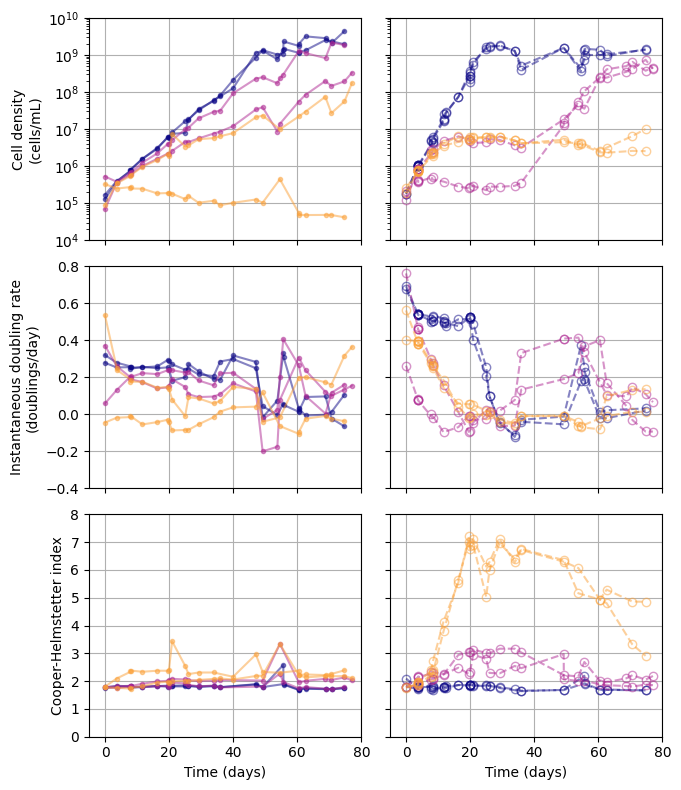

In [11]:
fig, axs = plt.subplots(3, 2, figsize=(7, 8))

color_i = 60
cmap = cm.plasma

ax = axs[0][0]
ax1 = axs[1][0]
ax2 = axs[2][0]
for sample in [1,2]:
  pp = df.loc[df['Flask'] == sample, ['Days', 'Cell density (cells/mL)']].dropna().T.values
  time = pp[0]
  cell_density=pp[1]

  ax.plot(time, cell_density,'.-', color=cmap(0), alpha=0.5)

  idr = get_idr(time, cell_density)
  ax1.plot(time, idr,'.-', color=cmap(0), alpha=0.5)

  time_ch_index = df.loc[df['Flask'] == sample, ['Days', 'CH index']].dropna().T.values
  ax2.plot(time_ch_index[0], time_ch_index[1],'.-', color=cmap(0), alpha=0.5)

for sample in [3,4]:
  pp = df.loc[df['Flask'] == sample, ['Days', 'Cell density (cells/mL)']].dropna().T.values
  time = pp[0]
  cell_density=pp[1]

  ax.plot(time, cell_density,'.-', color=cmap(100), alpha=0.5)

  idr = get_idr(time, cell_density)
  ax1.plot(time, idr,'.-', color=cmap(100), alpha=0.5)

  time_ch_index = df.loc[df['Flask'] == sample, ['Days', 'CH index']].dropna().T.values
  ax2.plot(time_ch_index[0], time_ch_index[1],'.-', color=cmap(100), alpha=0.5)

for sample in [5,6]:
  pp = df.loc[df['Flask'] == sample, ['Days', 'Cell density (cells/mL)']].dropna().T.values
  time = pp[0]
  cell_density=pp[1]

  ax.plot(time, cell_density,'.-', color=cmap(200), alpha=0.5)

  idr = get_idr(time, cell_density)
  ax1.plot(time, idr,'.-', color=cmap(200), alpha=0.5)

  time_ch_index = df.loc[df['Flask'] == sample, ['Days', 'CH index']].dropna().T.values
  ax2.plot(time_ch_index[0], time_ch_index[1],'.-', color=cmap(200), alpha=0.5)

ax = axs[0][1]
ax1 = axs[1][1]
ax2 = axs[2][1]
for sample in [7,8]:
  pp = df.loc[df['Flask'] == sample, ['Days', 'Cell density (cells/mL)']].dropna().T.values
  time = pp[0]
  cell_density=pp[1]

  ax.plot(time, cell_density,'o--', color=cmap(0), alpha=0.5, mfc='none')

  idr = get_idr(time, cell_density)
  ax1.plot(time, idr,'o--', color=cmap(0), alpha=0.5, mfc='none')

  time_ch_index = df.loc[df['Flask'] == sample, ['Days', 'CH index']].dropna().T.values
  ax2.plot(time_ch_index[0], time_ch_index[1],'o--', color=cmap(0), alpha=0.5, mfc='none')

for sample in [9,10]:
  pp = df.loc[df['Flask'] == sample, ['Days', 'Cell density (cells/mL)']].dropna().T.values
  time = pp[0]
  cell_density=pp[1]

  ax.plot(time, cell_density,'o--', color=cmap(100), alpha=0.5, mfc='none')

  idr = get_idr(time, cell_density)
  ax1.plot(time, idr,'o--', color=cmap(100), alpha=0.5, mfc='none')

  time_ch_index = df.loc[df['Flask'] == sample, ['Days', 'CH index']].dropna().T.values
  ax2.plot(time_ch_index[0], time_ch_index[1],'o--', color=cmap(100), alpha=0.5, mfc='none')

for sample in [11,12]:
  pp = df.loc[df['Flask'] == sample, ['Days', 'Cell density (cells/mL)']].dropna().T.values
  time = pp[0]
  cell_density=pp[1]

  ax.plot(time, cell_density,'o--', color=cmap(200), alpha=0.5, mfc='none')

  idr = get_idr(time, cell_density)
  ax1.plot(time, idr,'o--', color=cmap(200), alpha=0.5, mfc='none')

  time_ch_index = df.loc[df['Flask'] == sample, ['Days', 'CH index']].dropna().T.values
  ax2.plot(time_ch_index[0], time_ch_index[1],'o--', color=cmap(200), alpha=0.5, mfc='none')

for ax in axs.flatten():
  ax.set_xlim(-5, 80)
  ax.grid('on')

for ax in axs[0]:
  ax.set_xticklabels([])
  ax.set_yscale('log', base=10)
  ax.set_ylim(1e4, 1e10)

for ax in axs[1]:
  ax.set_xticklabels([])
  ax.set_ylim(-0.4,0.8)

for ax in axs[2]:
  ax.set_xlabel('Time (days)')
  ax.set_ylim(0,8)

axs[0][0].set_ylabel('Cell density\n(cells/mL)')
axs[0][1].set_yticklabels([])

axs[1][0].set_ylabel('Instantaneous doubling rate\n(doublings/day)')
axs[1][1].set_yticklabels([])

axs[2][0].set_ylabel('Cooper-Helmstetter index')
axs[2][1].set_yticklabels([])

fig.tight_layout()
fig.savefig('/content/Fig5a-f.pdf')
plt.show()

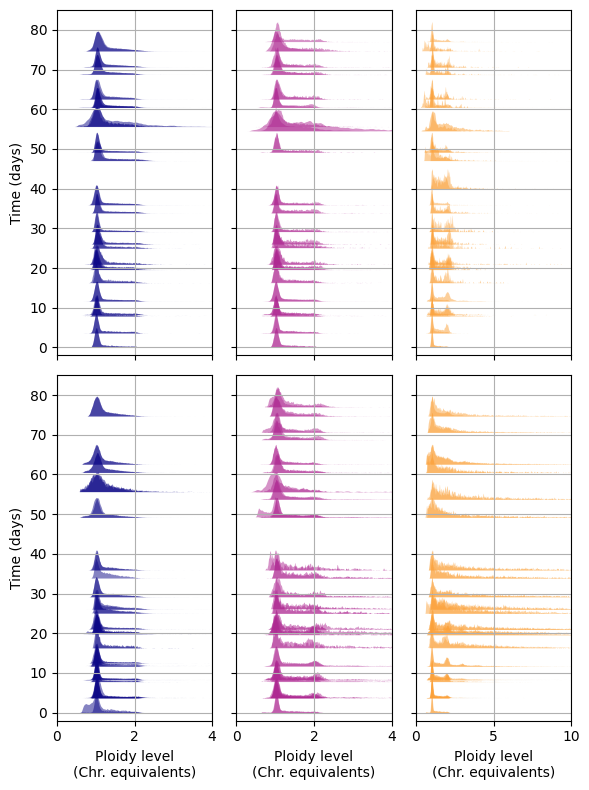

In [12]:
fig, axs = plt.subplots(2,3,figsize=(6,8))

ax = axs[0][0]
for sample in [1,2]:
  target_df = df.loc[df['Flask'] == sample, ['Days', 'Ploidy file']].dropna()
  for i in target_df.index:
    day = target_df.loc[i, 'Days']
    with open(df.loc[i, 'Ploidy file']) as json_file:
      data = json.load(json_file)

      X_range = (np.array(list(data.keys()))).astype(float)
      ploidy = (np.array(list(data.values()))).astype(float)

      ax.fill_between(X_range, day+5*ploidy, day, color=cmap(0), alpha=0.5, linewidth=0)
ax.set_xlim(0,4)

ax = axs[0][1]
for sample in [3,4]:
  target_df = df.loc[df['Flask'] == sample, ['Days', 'Ploidy file']].dropna()
  for i in target_df.index:
    day = target_df.loc[i, 'Days']
    with open(df.loc[i, 'Ploidy file']) as json_file:
      data = json.load(json_file)

      X_range = (np.array(list(data.keys()))).astype(float)
      ploidy = (np.array(list(data.values()))).astype(float)

      ax.fill_between(X_range, day+5*ploidy, day, color=cmap(100), alpha=0.5, linewidth=0)
ax.set_xlim(0,4)

ax = axs[0][2]
for sample in [5,6]:
  target_df = df.loc[df['Flask'] == sample, ['Days', 'Ploidy file']].dropna()
  for i in target_df.index:
    day = target_df.loc[i, 'Days']
    with open(df.loc[i, 'Ploidy file']) as json_file:
      data = json.load(json_file)

      X_range = (np.array(list(data.keys()))).astype(float)
      ploidy = (np.array(list(data.values()))).astype(float)

      ax.fill_between(X_range, day+5*ploidy, day, color=cmap(200), alpha=0.5, linewidth=0)
ax.set_xlim(0,10)

ax = axs[1][0]
for sample in [7,8]:
  target_df = df.loc[df['Flask'] == sample, ['Days', 'Ploidy file']].dropna()
  for i in target_df.index:
    day = target_df.loc[i, 'Days']
    with open(df.loc[i, 'Ploidy file']) as json_file:
      data = json.load(json_file)

      X_range = (np.array(list(data.keys()))).astype(float)
      ploidy = (np.array(list(data.values()))).astype(float)

      ax.fill_between(X_range, day+5*ploidy, day, color=cmap(0), alpha=0.5, linewidth=0)
ax.set_xlim(0,4)

ax = axs[1][1]
for sample in [9,10]:
  target_df = df.loc[df['Flask'] == sample, ['Days', 'Ploidy file']].dropna()
  for i in target_df.index:
    day = target_df.loc[i, 'Days']
    with open(df.loc[i, 'Ploidy file']) as json_file:
      data = json.load(json_file)

      X_range = (np.array(list(data.keys()))).astype(float)
      ploidy = (np.array(list(data.values()))).astype(float)

      ax.fill_between(X_range, day+5*ploidy, day, color=cmap(100), alpha=0.5, linewidth=0)
ax.set_xlim(0,4)

ax = axs[1][2]
for sample in [11,12]:
  target_df = df.loc[df['Flask'] == sample, ['Days', 'Ploidy file']].dropna()
  for i in target_df.index:
    day = target_df.loc[i, 'Days']
    with open(df.loc[i, 'Ploidy file']) as json_file:
      data = json.load(json_file)

      X_range = (np.array(list(data.keys()))).astype(float)
      ploidy = (np.array(list(data.values()))).astype(float)

      ax.fill_between(X_range, day+5*ploidy, day, color=cmap(200), alpha=0.5, linewidth=0)

ax.set_xlim(0,10)

for ax in axs.flatten():
  ax.grid()
  ax.set_ylim(-2,85)

for ax in axs[0]:
  ax.set_xticklabels([])
for ax in axs[0][1:3]:
  ax.set_yticklabels([])
for ax in axs[1][1:3]:
  ax.set_yticklabels([])

for ax in (axs[0][0], axs[1][0]):
  ax.set_ylabel('Time (days)')
for ax in axs[1]:
  ax.set_xlabel('Ploidy level\n(Chr. equivalents)')

fig.tight_layout()
fig.savefig('/content/Fig5g-l.pdf')
plt.show()